In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
from scipy.interpolate import interp1d

import warnings
warnings.filterwarnings("ignore")

%matplotlib widget

In [2]:
input_file = '/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/ngc1783_catalog.csv'
df = pd.read_csv(input_file)

# rename columns of the filters
df.rename(columns={'F275Wu':'F275W', 'F336Wu':'F336W', 'F343Nu':'F343N', 'F435Wa':'F435W', 'F555Wa':'F555W', 'F814Wa':'F814W'}, inplace=True)

print(df)

             Xpos       Ypos    F275W  e_F275Wu  o_F275Wu  n_F275Wu  q_F275Wu  \
0       5090.7178  1271.4926      NaN       NaN         0         0         0   
1       5099.0498  1303.9301      NaN       NaN         0         0         0   
2       5107.5757  1313.3196      NaN       NaN         0         0         0   
3       5110.5039  1305.3313      NaN       NaN         0         0         0   
4       5118.0532  1320.9412      NaN       NaN         0         0         0   
...           ...        ...      ...       ...       ...       ...       ...   
247361  6228.8184  6196.5352      NaN       NaN         6         0         0   
247362  3985.0969  5295.8145  24.6808    0.0712         4         2         1   
247363  4880.4912  4396.8486      NaN       NaN         6         0         0   
247364  3949.7500  7996.6250      NaN       NaN         2         0         0   
247365  8458.8281  4394.2710      NaN       NaN         0         0         0   

          F336W  e_F336Wu  

In [3]:
data = df[(df['q_F275Wu'] == 1) &
          (df['q_F336Wu'] == 1) &
          (df['q_F343Nu'] == 1) &
          (df['q_F435Wa'] == 1) &
          (df['q_F555Wa'] == 1) &
          (df['q_F814Wa'] == 1)
]

In [4]:
# center and approximative radius of the cluster
center_1783 = np.array([5000,5500])
radius_1783 = 700

# center and radius of the reference field
center_ref = np.array([3750,6250])
radius_ref = 500

data['distance_1783'] = np.sqrt((data['Xpos']-center_1783[0])**2 + (data['Ypos']-center_1783[1])**2)
data['distance_reference'] = np.sqrt((data['Xpos']-center_ref[0])**2 + (data['Ypos']-center_ref[1])**2)

data_1783 = data[data['distance_1783'] < radius_1783]
data_ref = data[data['distance_reference'] < radius_ref]


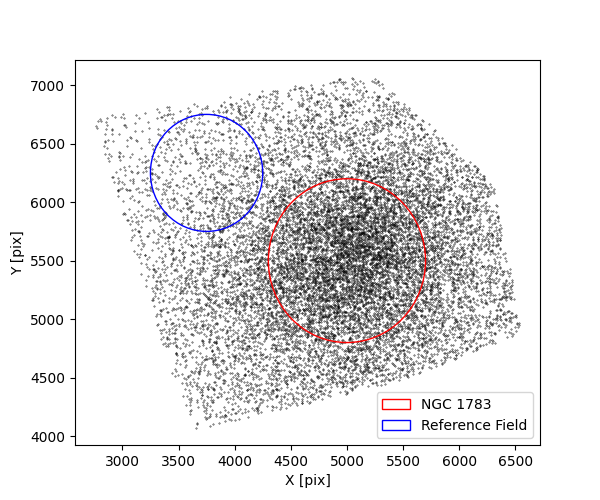

In [17]:
plt.figure(figsize=(6,5))

plt.scatter(data['Xpos'], data['Ypos'], s=0.1, c='black')
circle_1783 = plt.Circle((center_1783[0], center_1783[1]), radius_1783, color='red', fill=False, label='NGC 1783')
plt.gca().add_artist(circle_1783)
circle_ref = plt.Circle((center_ref[0], center_ref[1]), radius_ref, color='blue', fill=False, label='Reference Field')
plt.gca().add_artist(circle_ref)

plt.xlabel('X [pix]')
plt.ylabel('Y [pix]')
plt.legend()

plt.show()


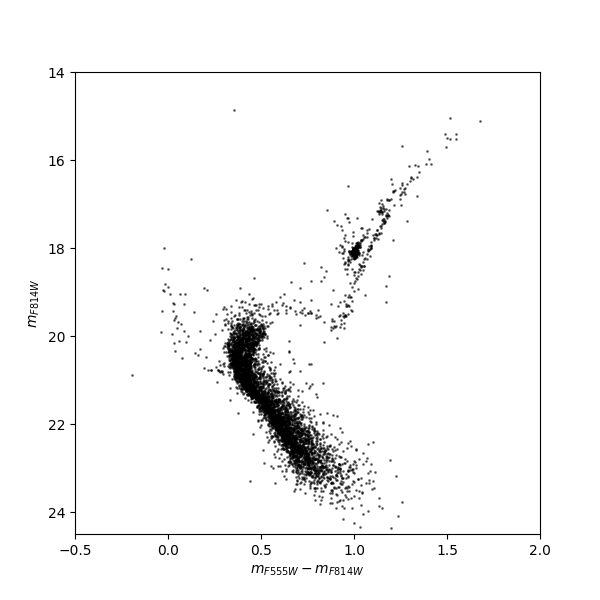

In [19]:
plt.figure(figsize=(6,6))

plt.scatter(data_1783['F555W']-data_1783['F814W'], data_1783['F814W'], s=1, c='black', alpha=0.5)

plt.gca().invert_yaxis()
plt.xlim(-0.5,2)
plt.ylim(24.5, 14)

plt.xlabel(r'$m_{F555W} - m_{F814W}$')
plt.ylabel(r'$m_{F814W}$')

plt.show()

## Select fiducials 

In [8]:
import sys
import os

# set the path to the tools folder
module_path = '/Users/giadaaggio/Desktop/Thesis/TOTORO/CODES/tools'
sys.path.append(module_path)

from CMDAnalyzer import CMDFiducialSelector

In [33]:
select = False

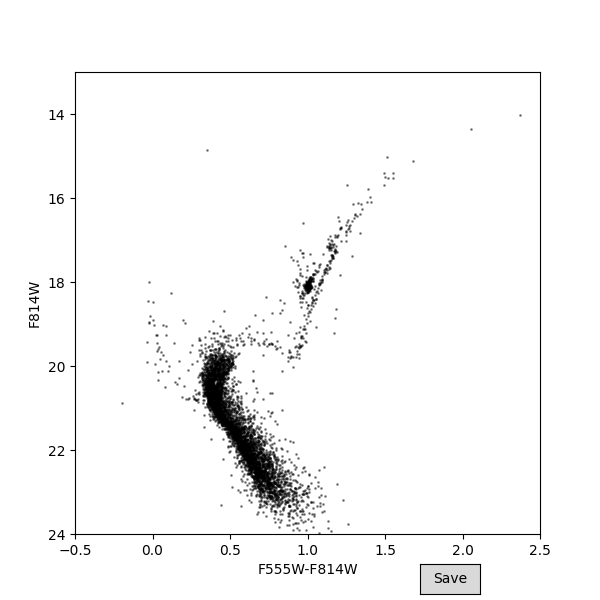

Selected point: (0.539, 16.500)
Selected point: (1.021, 17.929)
Selected point: (1.006, 18.051)
Selected point: (1.003, 18.142)
Fiducial line saved to /Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_555_814.csv


In [22]:
if select == True:
    fiducial_555_814 = CMDFiducialSelector(
        data=data_1783, 
        color=data_1783['F555W']-data_1783['F814W'], 
        magnitude=data_1783['F814W'],
        x_label="F555W-F814W",  # Example color index
        y_label="F814W",  # Example magnitude
        output_file="/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_555_814.csv",
        xlim=(-0.5,2.5),
        ylim=(24, 13),
        invert_yaxis=False,
    )

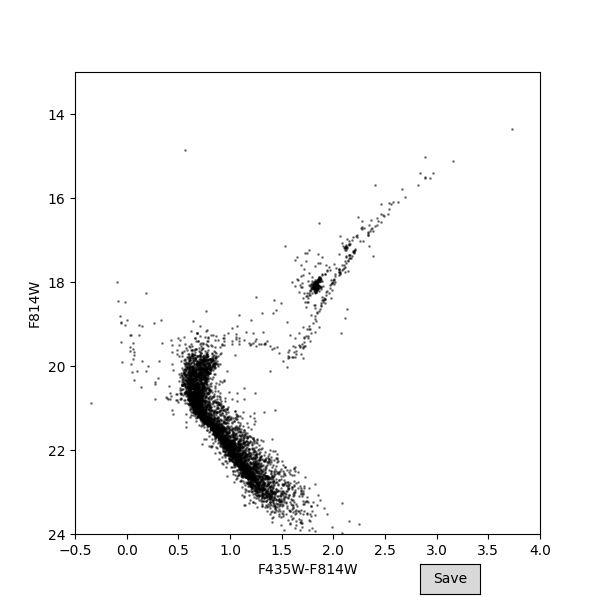

Selected point: (1.794, 18.190)
Selected point: (1.852, 18.024)
Selected point: (1.910, 17.810)
Fiducial line saved to /Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_435_814.csv


In [24]:
if select == True:
    fiducial_435_814 = CMDFiducialSelector(
        data=data_1783, 
        color=data_1783['F435W']-data_1783['F814W'], 
        magnitude=data_1783['F814W'],
        x_label="F435W-F814W",  # Example color index
        y_label="F814W",  # Example magnitude
        output_file="/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_435_814.csv",
        xlim=(-0.5,4),
        ylim=(24, 13),
        invert_yaxis=False,
    )

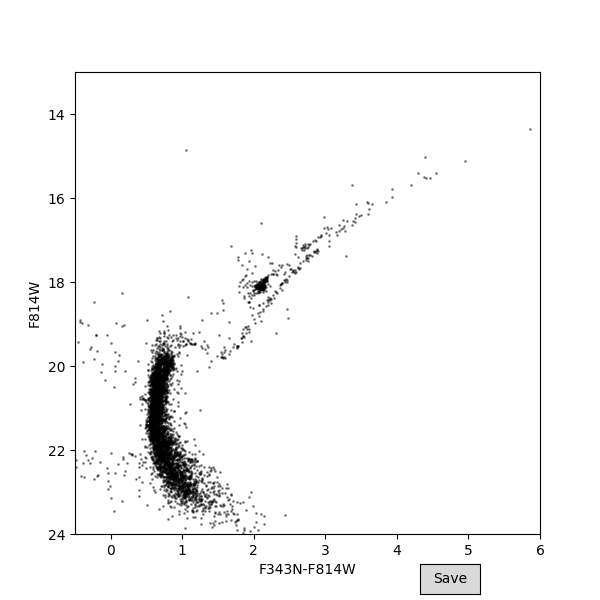

Selected point: (2.002, 18.167)
Selected point: (2.100, 18.071)
Selected point: (2.198, 17.929)
Fiducial line saved to /Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_343_814.csv


In [26]:
if select == True:
    fiducial_343_814 = CMDFiducialSelector(
        data=data_1783, 
        color=data_1783['F343N']-data_1783['F814W'], 
        magnitude=data_1783['F814W'],
        x_label="F343N-F814W",  # Example color index
        y_label="F814W",  # Example magnitude
        output_file="/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_343_814.csv",
        xlim=(-0.5,6),
        ylim=(24, 13),
        invert_yaxis=False,
    )

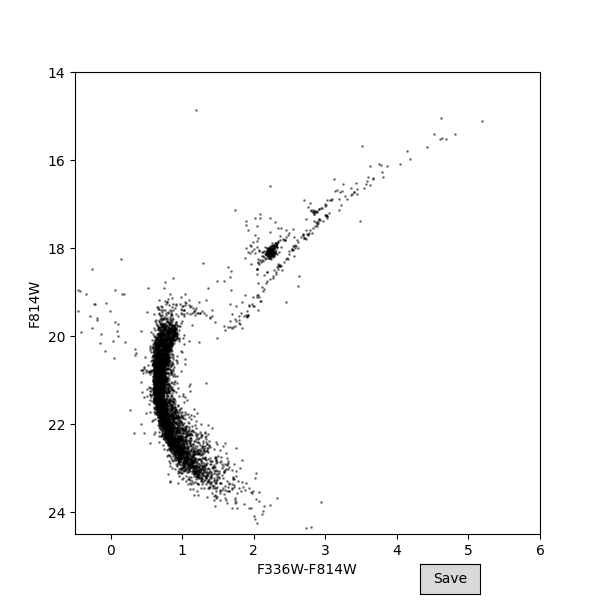

Selected point: (2.142, 18.205)
Selected point: (2.268, 18.091)
Selected point: (2.352, 17.932)
Fiducial line saved to /Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_336_814.csv


In [29]:
if select == True:
    fiducial_336_814 = CMDFiducialSelector(
        data=data_1783, 
        color=data_1783['F336W']-data_1783['F814W'], 
        magnitude=data_1783['F814W'],
        x_label="F336W-F814W",  # Example color index
        y_label="F814W",  # Example magnitude
        output_file="/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_336_814.csv",
        xlim=(-0.5,6),
        ylim=(24.5, 14),
        invert_yaxis=False,
    )

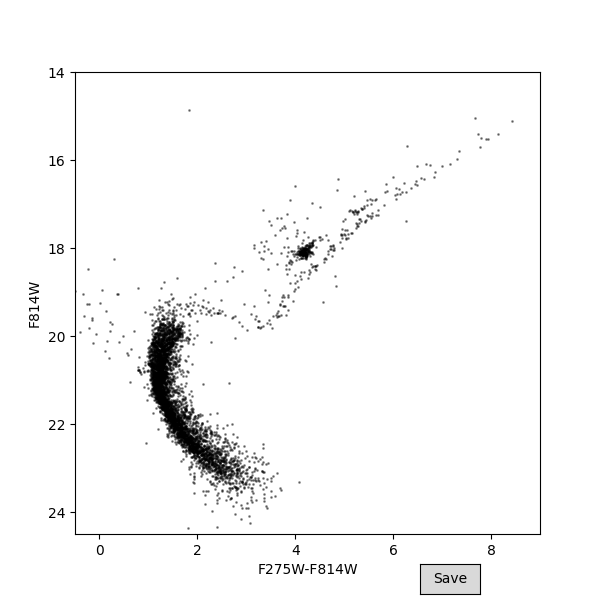

Selected point: (4.015, 18.114)
Selected point: (4.178, 18.023)
Selected point: (4.362, 17.886)
Fiducial line saved to /Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_275_814.csv


In [31]:
if select == True:
    fiducial_275_814 = CMDFiducialSelector(
        data=data_1783, 
        color=data_1783['F275W']-data_1783['F814W'], 
        magnitude=data_1783['F814W'],
        x_label="F275W-F814W",  # Example color index
        y_label="F814W",  # Example magnitude
        output_file="/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_275_814.csv",
        xlim=(-0.5,9),
        ylim=(24.5, 14),
        invert_yaxis=False,
    )

## Select test stars

In [37]:
# main sequence fiducials
fiducial_555_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/fid_1783_555_814.csv')
fiducial_435_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/fid_1783_435_814.csv')
fiducial_343_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/fid_1783_343_814.csv')
fiducial_336_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/fid_1783_336_814.csv')
fiducial_275_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/fid_1783_275_814.csv')

# HB fiducials
HB_555_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_555_814.csv')
HB_435_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_435_814.csv')
HB_343_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_343_814.csv')
HB_336_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_336_814.csv')
HB_275_814 = pd.read_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/HB_1783_275_814.csv')

In [47]:
mags = [23, 22.5, 22, 21.5, 21, 20.5, 20, 19.5, 19, 18.5, 18, 17.5, 17, 16.5, 16, 15.5]
mags_HB = [18.2, 18, 17.9]

test_stars = pd.DataFrame()
test_stars['F814W'] = mags

hb_stars = pd.DataFrame()
hb_stars['F814W'] = mags_HB

def build_test_star(test_stars, hb_stars, mags, fiducial, fiducial_HB, filter_B):
    x_val = fiducial['X']
    y_val = fiducial['Y']

    # interpolate for the main sequence
    interp_func = interp1d(y_val, x_val, kind='linear', fill_value='extrapolate')
    colors = interp_func(mags)
    mags_2 = colors + mags

    test_stars[filter_B] = mags_2

    # interpolate for the HB

    x_val_HB = fiducial_HB['X']
    y_val_HB = fiducial_HB['Y']

    interp_func_HB = interp1d(y_val_HB, x_val_HB, kind='linear', fill_value='extrapolate')
    colors_HB = interp_func_HB(mags_HB)

    hb_stars[filter_B] = colors_HB + hb_stars['F814W']

    return test_stars, hb_stars


In [48]:
test_stars_1, hb_stars_1 = build_test_star(test_stars, hb_stars, mags, fiducial_555_814, HB_555_814, 'F555W')
test_stars_2, hb_stars_2 = build_test_star(test_stars_1, hb_stars_1, mags, fiducial_435_814, HB_435_814, 'F435W')
test_stars_3, hb_stars_3 = build_test_star(test_stars_2, hb_stars_2, mags, fiducial_343_814, HB_343_814, 'F343W')
test_stars_4, hb_stars_4 = build_test_star(test_stars_3, hb_stars_3, mags, fiducial_336_814, HB_336_814, 'F336W')
test_stars_5, hb_stars_5 = build_test_star(test_stars_4, hb_stars_4, mags, fiducial_275_814, HB_275_814, 'F275W')

test_stars_5['source'] = 'test_stars'
hb_stars_5['source'] = 'HB_test_stars'

In [56]:
test_set_final = pd.concat([test_stars_5, hb_stars_5], ignore_index=True)

# Save the test set
#test_set_final.to_csv('/Users/giadaaggio/Desktop/Thesis/TOTORO/FITS/NGC1783/test_stars_NGC1783.csv', index=False, sep=' ', float_format='%.4f')

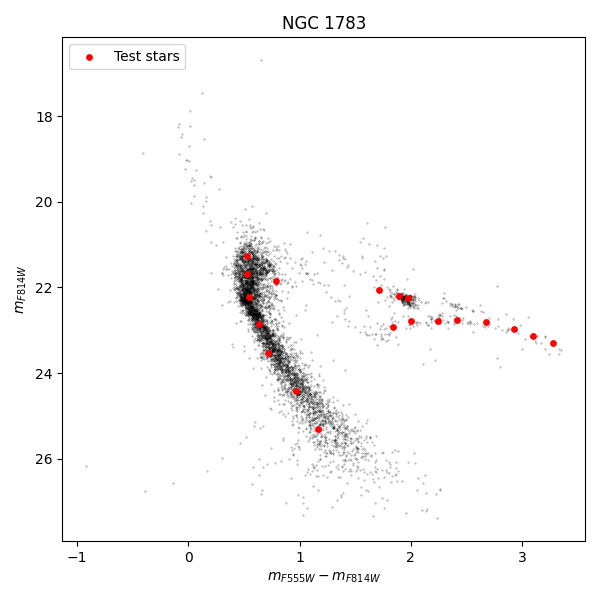

In [58]:
# Optical CMD
fig, ax = plt.subplots(figsize=(6, 6))
plt.scatter(data_1783['F275W']-data_1783['F336W'], data_1783['F275W'], s=0.1, alpha=0.5, c='black')
plt.scatter(test_set_final['F275W']-test_set_final['F336W'], test_set_final['F275W'], s=15, alpha=1, c='red', zorder=2, label='Test stars')

plt.gca().invert_yaxis()

#ax.set_xlim(-0.5,2)
#ax.set_ylim(24.5, 14)
plt.legend(loc='upper left')
plt.xlabel(r'$m_{F555W}-m_{F814W}$')
plt.ylabel(r'$m_{F814W}$')
plt.title('NGC 1783')

plt.tight_layout()
plt.show()